# 03 · Evaluation Result — Seq2Seq LSTM (Jena Climate)

Notebook phục vụ **Slide 8: Evaluation Result**.

## PHẦN 1 — Giới thiệu notebook

**Mục tiêu notebook:**
- Load checkpoint model (`Seq2SeqLSTM`) đã training xong — checkpoint thật, không train lại.
- Predict trên test dataset thật (`data/processed/test.csv`).
- Calculate evaluation metrics bằng module có sẵn của project (`src/evaluation/metrics.py`).
- Visualize forecasting performance (Actual vs Prediction, RMSE theo horizon).

**Ràng buộc:** không tạo dữ liệu giả, không tự implement lại metric, không train lại model,
không hard-code đường dẫn khi project đã có config/schema mô tả đường dẫn đó.


## PHẦN 2 — Load Environment

**Input:** không có (chỉ import).

**Processing:**
- Thư viện nền tảng: `torch` (load checkpoint + inference), `numpy`/`pandas` (xử lý mảng/bảng),
  `matplotlib` (vẽ biểu đồ), `joblib` (nạp scaler).
- Module project (đường dẫn thật trong repo — lưu ý project **không có** module tên
  `src.dataset`; dataset thật nằm ở `src.data.dataset`):
  - `src.data.dataset.WeatherForecastDataset`, `src.data.dataloader.build_dataloader`
  - `src.data.validator.TIMESTAMP_COLUMN`
  - `src.models.seq2seq_lstm.Seq2SeqLSTM`
  - `src.evaluation.metrics` (`compute_metrics`, `compute_per_horizon_metrics`, `inverse_scale_target`)
  - `src.evaluation.error_analysis.build_error_frame`
  - `src.evaluation.visualization.save_forecast_figure`
  - `src.utils.config.load_config`, `src.utils.io.read_json`

Không có logic nào bị viết lại — toàn bộ đến từ module đã có sẵn trong project.

**Output:** môi trường sẵn sàng.


In [1]:
import sys
from pathlib import Path

# Quy ước giống các notebook khác của project: PROJECT_ROOT là thư mục cha của notebooks/
PROJECT_ROOT = Path.cwd().parent if (Path.cwd() / "notebooks").exists() is False else Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json

import joblib
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src.utils.config import load_config
from src.utils.io import read_json
from src.data.dataset import WeatherForecastDataset
from src.data.dataloader import build_dataloader
from src.data.validator import TIMESTAMP_COLUMN
from src.models.seq2seq_lstm import Seq2SeqLSTM
from src.evaluation.metrics import (
    compute_metrics,
    compute_per_horizon_metrics,
    inverse_scale_target,
)
from src.evaluation.error_analysis import build_error_frame
from src.evaluation.visualization import save_forecast_figure

print(f"[Setup] PROJECT_ROOT: {PROJECT_ROOT}")
print(f"[Setup] PyTorch version: {torch.__version__}")
print(f"[Setup] CUDA available: {torch.cuda.is_available()}")
print("[Setup] Environment sẵn sàng.")


[Setup] PROJECT_ROOT: E:\Project_Deep\Project_DL_Weather_Forecasting
[Setup] PyTorch version: 2.13.0+cpu
[Setup] CUDA available: False
[Setup] Environment sẵn sàng.


## PHẦN 3 — Load Checkpoint

**Input:**
- `runs/seq2seq_lstm/seq2seq_lstm_20260917_055727_50fe09/best_checkpoint.pt` (checkpoint thật, 15/15 epoch)
- `runs/seq2seq_lstm/seq2seq_lstm_20260917_055727_50fe09/resolved_config.yaml`
- `runs/seq2seq_lstm/seq2seq_lstm_20260917_055727_50fe09/run_record.json`
- `artifacts/preprocessing/feature_schema.json`

**Processing:** đọc config + schema (`load_config`, `read_json` — module có sẵn), dựng lại
kiến trúc `Seq2SeqLSTM` đúng hyperparameter của run, `load_state_dict(strict=True)`, chuyển
sang `eval()`.

**Output:** model đã load thành công trên đúng device, in ra Model name / Run ID / Epoch /
Validation metric của checkpoint.


In [2]:
RUN_DIR = PROJECT_ROOT / "runs" / "seq2seq_lstm" / "seq2seq_lstm_20260917_055727_50fe09"
CHECKPOINT_PATH = RUN_DIR / "best_checkpoint.pt"
CONFIG_PATH = RUN_DIR / "resolved_config.yaml"
SCHEMA_PATH = PROJECT_ROOT / "artifacts" / "preprocessing" / "feature_schema.json"

assert CHECKPOINT_PATH.is_file(), f"Chưa có artifact: checkpoint không tồn tại tại {CHECKPOINT_PATH}"
assert CONFIG_PATH.is_file(), f"Chưa có artifact: resolved_config.yaml không tồn tại tại {CONFIG_PATH}"
assert SCHEMA_PATH.is_file(), f"Chưa có artifact: feature_schema.json không tồn tại tại {SCHEMA_PATH}"

resolved_config = load_config(CONFIG_PATH)
run_record = read_json(RUN_DIR / "run_record.json")
RUN_ID = run_record["run_id"]

schema = read_json(SCHEMA_PATH)
ordered_features = schema["ordered_features"]
n_features = schema["n_features"]
target_name = schema["target"]["name"]
target_index = schema["target"]["index"]
input_length = schema["window_contract"]["input_len_hours"]
horizon = schema["window_contract"]["horizon_hours"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=True)

encoder_input_size = checkpoint["model_state_dict"]["encoder.lstm.weight_ih_l0"].shape[1]
assert encoder_input_size == n_features, (
    f"Checkpoint train với n_features={encoder_input_size}, schema hiện tại n_features={n_features}"
)

model_cfg = resolved_config["model"]
model = Seq2SeqLSTM(
    n_features=n_features,
    target_feature_index=target_index,
    hidden_size=model_cfg["hidden_size"],
    num_layers=model_cfg["num_layers"],
    dropout=model_cfg["dropout"],
    horizon=model_cfg["horizon"],
)
model.load_state_dict(checkpoint["model_state_dict"], strict=True)
model.to(device)
model.eval()

print(f"Model name: {type(model).__name__}")
print(f"Run ID: {RUN_ID}")
print(f"Epoch (best checkpoint): {checkpoint['epoch']}")
print(f"Validation metric (val_loss tại epoch này): {checkpoint['metrics']['val_loss']:.6f}")
print(f"Validation metric (best_value ghi trong checkpoint): {checkpoint['best_value']:.6f}")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Device: {device}")
print("Model loaded successfully")


Model name: Seq2SeqLSTM
Run ID: seq2seq_lstm_20260917_055727_50fe09
Epoch (best checkpoint): 13
Validation metric (val_loss tại epoch này): 0.144005
Validation metric (best_value ghi trong checkpoint): 0.144005
Number of parameters: 142,977
Device: cpu
Model loaded successfully


## PHẦN 4 — Load Test Dataset

**Input:** `data/processed/test.csv`

- Input: 168 giờ lịch sử, 18 features
- Output: 72 giờ nhiệt độ tương lai

**Processing:** dựng `WeatherForecastDataset` (module có sẵn `src/data/dataset.py`, TV2) trên
`test.csv`, sau đó `build_dataloader` (không shuffle, giữ đúng thứ tự thời gian).

**Output:** `X_test shape: [batch,168,18]`, `y_test shape: [batch,72,1]` — kiểm tra bằng dữ liệu
thật, không giả định.


In [3]:
TEST_CSV_PATH = PROJECT_ROOT / "data" / "processed" / "test.csv"
assert TEST_CSV_PATH.is_file(), f"Chưa có artifact: {TEST_CSV_PATH}"

test_df = pd.read_csv(TEST_CSV_PATH)
assert TIMESTAMP_COLUMN in test_df.columns, f"Thiếu cột timestamp '{TIMESTAMP_COLUMN}'"

test_dataset = WeatherForecastDataset(
    df=test_df,
    features=ordered_features,
    target=target_name,
    input_window=input_length,
    horizon=horizon,
)
n_test_samples = len(test_dataset)

BATCH_SIZE = 64
test_loader = build_dataloader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
batch0 = next(iter(test_loader))

print(f"test.csv: {test_df.shape[0]} dòng x {test_df.shape[1]} cột")
print(f"Số cửa sổ (samples) hợp lệ trong test set: {n_test_samples}")
print(f"X_test shape: [batch,{input_length},{n_features}]  (1 batch thật: {tuple(batch0['x'].shape)})")
print(f"y_test shape: [batch,{horizon},1]  (1 batch thật: {tuple(batch0['y'].shape)})")


test.csv: 10520 dòng x 33 cột
Số cửa sổ (samples) hợp lệ trong test set: 9969
X_test shape: [batch,168,18]  (1 batch thật: (64, 168, 18))
y_test shape: [batch,72,1]  (1 batch thật: (64, 72, 1))


## PHẦN 5 — Inference

**Input:** `X_test` từ `test_loader` (Phần 4).

**Processing:** `model(x_test, y=None, teacher_forcing_ratio=0.0)` — bắt buộc `y=None` theo
Model Contract v1 / `EVALUATION_RULES.md` (không rò rỉ target vào model). **Không train lại**
— chỉ chạy `torch.no_grad()` + `model.eval()`.

**Output:** `y_pred`, kiểm tra `prediction shape: [batch,72,1]` trên toàn bộ test set.


In [4]:
y_true_chunks, y_pred_chunks, timestamp_chunks = [], [], []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        x = batch["x"].to(device)
        y = batch["y"].to(device)
        y_pred_batch = model(x, y=None, teacher_forcing_ratio=0.0)

        y_true_chunks.append(y.cpu().numpy())
        y_pred_chunks.append(y_pred_batch.cpu().numpy())
        timestamp_chunks.append(batch["target_timestamps"].numpy())

y_true_scaled = np.concatenate(y_true_chunks, axis=0)  # [N,72,1]
y_pred_scaled = np.concatenate(y_pred_chunks, axis=0)  # [N,72,1]
target_timestamps = np.concatenate(timestamp_chunks, axis=0)  # [N,72]

assert y_pred_scaled.shape == (n_test_samples, horizon, 1), "prediction shape không khớp [batch,72,1]"
print(f"prediction shape: {y_pred_scaled.shape}  (kỳ vọng [batch,72,1])")
print("Kiểm tra shape: ĐẠT")


prediction shape: (9969, 72, 1)  (kỳ vọng [batch,72,1])
Kiểm tra shape: ĐẠT


## PHẦN 6 — Inverse Scaling

**Giải thích:** `test.csv` đã được `StandardScaler` chuẩn hóa ở bước preprocessing, nên
`y_true`/`y_pred` ở Phần 5 đang ở dạng scaled prediction, chưa phải nhiệt độ thật.

**Input:** `y_true_scaled`, `y_pred_scaled` (Phần 5) và scaler thật tại
`data/processed/scaler.joblib`.

**Lưu ý:** project có 2 file scaler — `artifacts/preprocessing/scaler.joblib` (fit trên 18
feature) và `data/processed/scaler.joblib` (fit trên 32 cột, gồm cả các cột `missing_*`).
Theo yêu cầu notebook này, dùng đúng `data/processed/scaler.joblib`. Hai file khác `n_features_in_`
nhưng **cùng giá trị `mean_`/`scale_` tại đúng `target_index`** (kiểm tra bằng assert bên dưới),
nên kết quả inverse-scale nhiệt độ không đổi dù dùng file nào.

**Processing:** `inverse_scale_target()` — hàm có sẵn trong `src/evaluation/metrics.py`,
không viết lại.

**Output:** scaled prediction → nhiệt độ °C thật (`y_true_degC`, `y_pred_degC`, shape `[N,72]`).


In [5]:
SCALER_PATH = PROJECT_ROOT / "data" / "processed" / "scaler.joblib"
assert SCALER_PATH.is_file(), f"Chưa có artifact: {SCALER_PATH}"

scaler = joblib.load(SCALER_PATH)

reference_scaler = joblib.load(PROJECT_ROOT / "artifacts" / "preprocessing" / "scaler.joblib")
assert scaler.mean_[target_index] == reference_scaler.mean_[target_index]
assert scaler.scale_[target_index] == reference_scaler.scale_[target_index]

y_true_degC = inverse_scale_target(y_true_scaled[..., 0], scaler, target_index)  # [N,72]
y_pred_degC = inverse_scale_target(y_pred_scaled[..., 0], scaler, target_index)  # [N,72]

print(f"y_true (°C): shape={y_true_degC.shape} min={y_true_degC.min():.2f} max={y_true_degC.max():.2f}")
print(f"y_pred (°C): shape={y_pred_degC.shape} min={y_pred_degC.min():.2f} max={y_pred_degC.max():.2f}")


y_true (°C): shape=(9969, 72) min=-13.69 max=34.26
y_pred (°C): shape=(9969, 72) min=-11.21 max=32.93


E:\Project_Deep\Project_DL_Weather_Forecasting\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## PHẦN 7 — Evaluation

**Bắt buộc dùng `src/evaluation/metrics.py`, không tự implement lại.**

**Input:** `y_true_degC`, `y_pred_degC` (Phần 6).

**Processing:** `compute_metrics(y_true_degC, y_pred_degC)`.

**Output:** bảng MAE / RMSE / MSE (°C).


In [6]:
overall_metrics = compute_metrics(y_true_degC, y_pred_degC)
print(json.dumps(overall_metrics, indent=2, ensure_ascii=False))

metrics_table = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MSE"],
    "Value": [overall_metrics["mae"], overall_metrics["rmse"], overall_metrics["mse"]],
    "Unit": ["°C", "°C", "°C²"],
})
display(metrics_table)


{
  "mae": 2.518667361584161,
  "mse": 10.648307216196612,
  "rmse": 3.263174407872894
}


,Metric,Value,Unit
0,MAE,2.518667,°C
1,RMSE,3.263174,°C
2,MSE,10.648307,°C²


## PHẦN 8 — Horizon Analysis

**Input:** `y_true_degC`, `y_pred_degC` (Phần 6).

**Processing:** `compute_per_horizon_metrics()` — module có sẵn, trả 72 dòng MAE/RMSE/MSE
theo từng giờ dự báo.

**Output:** bảng lỗi tại các mốc 1h / 24h / 48h / 72h.


In [7]:
per_horizon = compute_per_horizon_metrics(y_true_degC, y_pred_degC)
per_horizon_df = pd.DataFrame(per_horizon)[["horizon", "mae", "rmse"]]
per_horizon_df.columns = ["Horizon", "MAE", "RMSE"]

key_hours = [1, 24, 48, 72]
horizon_table = per_horizon_df[per_horizon_df["Horizon"].isin(key_hours)].copy()
horizon_table["Horizon"] = horizon_table["Horizon"].astype(str) + "h"
display(horizon_table)


,Horizon,MAE,RMSE
0,1h,0.608590,0.798765
23,24h,2.355049,2.977954
47,48h,2.842059,3.608607
71,72h,3.122340,3.912408


## PHẦN 9 — Visualization

**Input:** `y_true_degC`, `y_pred_degC`, `target_timestamps` (Phần 6), `per_horizon_df` (Phần 8).

**Processing:**
1. `build_error_frame()` (module có sẵn, `src/evaluation/error_analysis.py`) rồi
   `save_forecast_figure()` (module có sẵn, `src/evaluation/visualization.py`) — vẽ Actual vs
   Prediction cho 1 cửa sổ test đại diện (`sample_index=0`, hành vi mặc định của hàm).
2. RMSE theo horizon: project **chưa có sẵn** hàm vẽ dạng này (`save_residual_figure` vẽ
   residual scatter, khác biểu đồ RMSE-theo-horizon yêu cầu ở đây) nên vẽ trực tiếp từ
   `per_horizon_df` đã tính ở Phần 8 bằng `matplotlib` (không tính lại metric).

**Output:**
- `artifacts/figures/forecast_vs_actual.png`
- `artifacts/figures/horizon_error.png`


Đã lưu: E:\Project_Deep\Project_DL_Weather_Forecasting\artifacts\figures\forecast_vs_actual.png


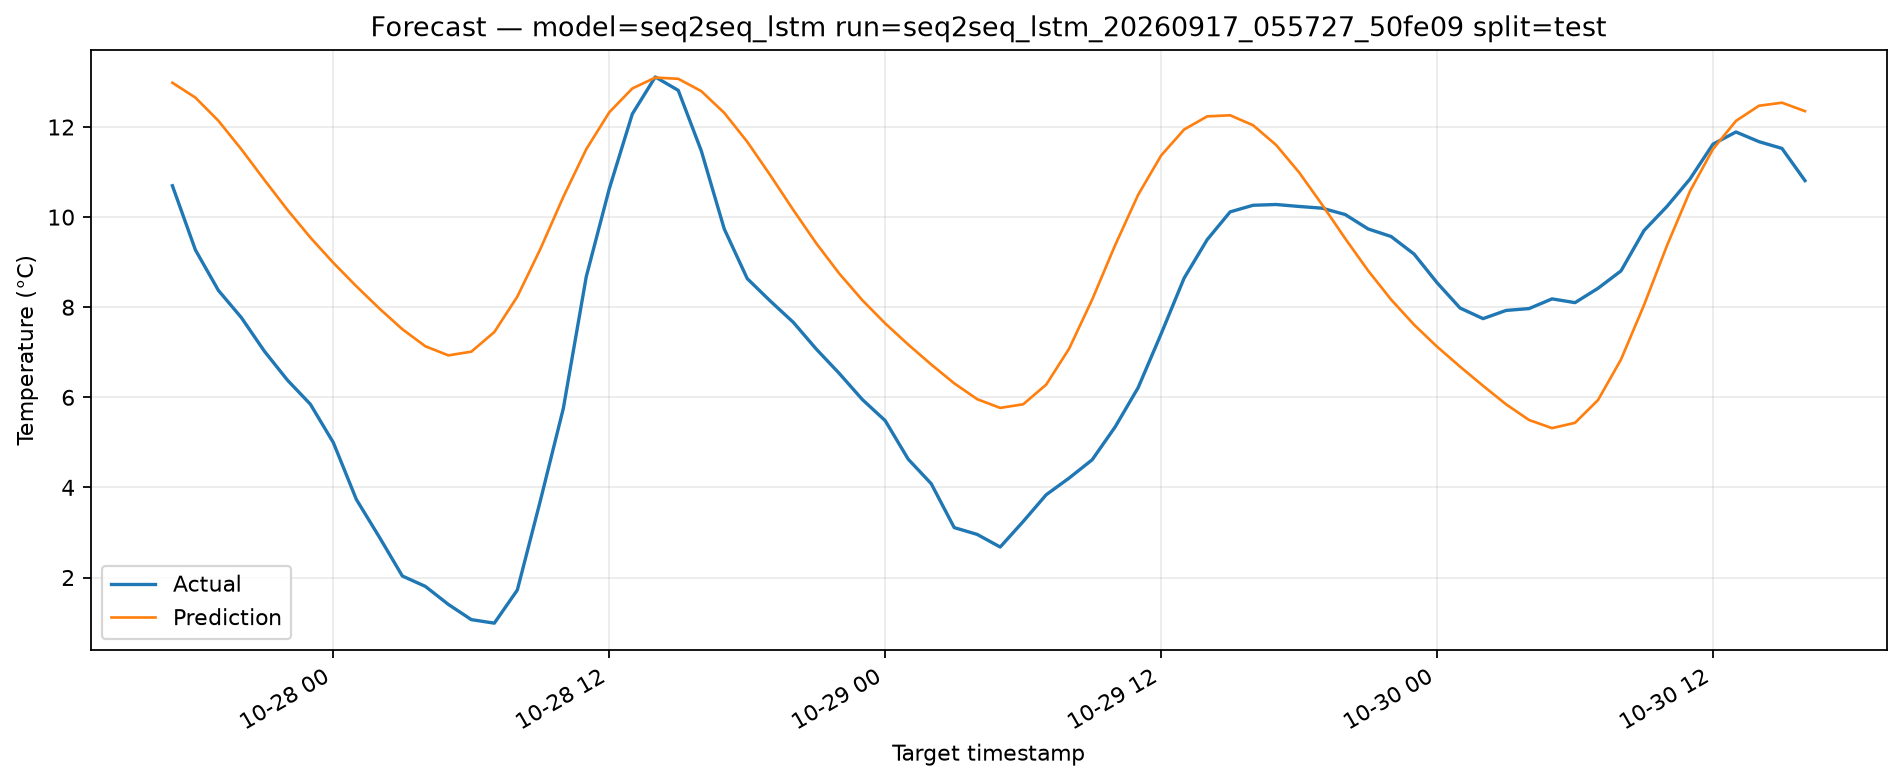

Đã lưu: E:\Project_Deep\Project_DL_Weather_Forecasting\artifacts\figures\horizon_error.png


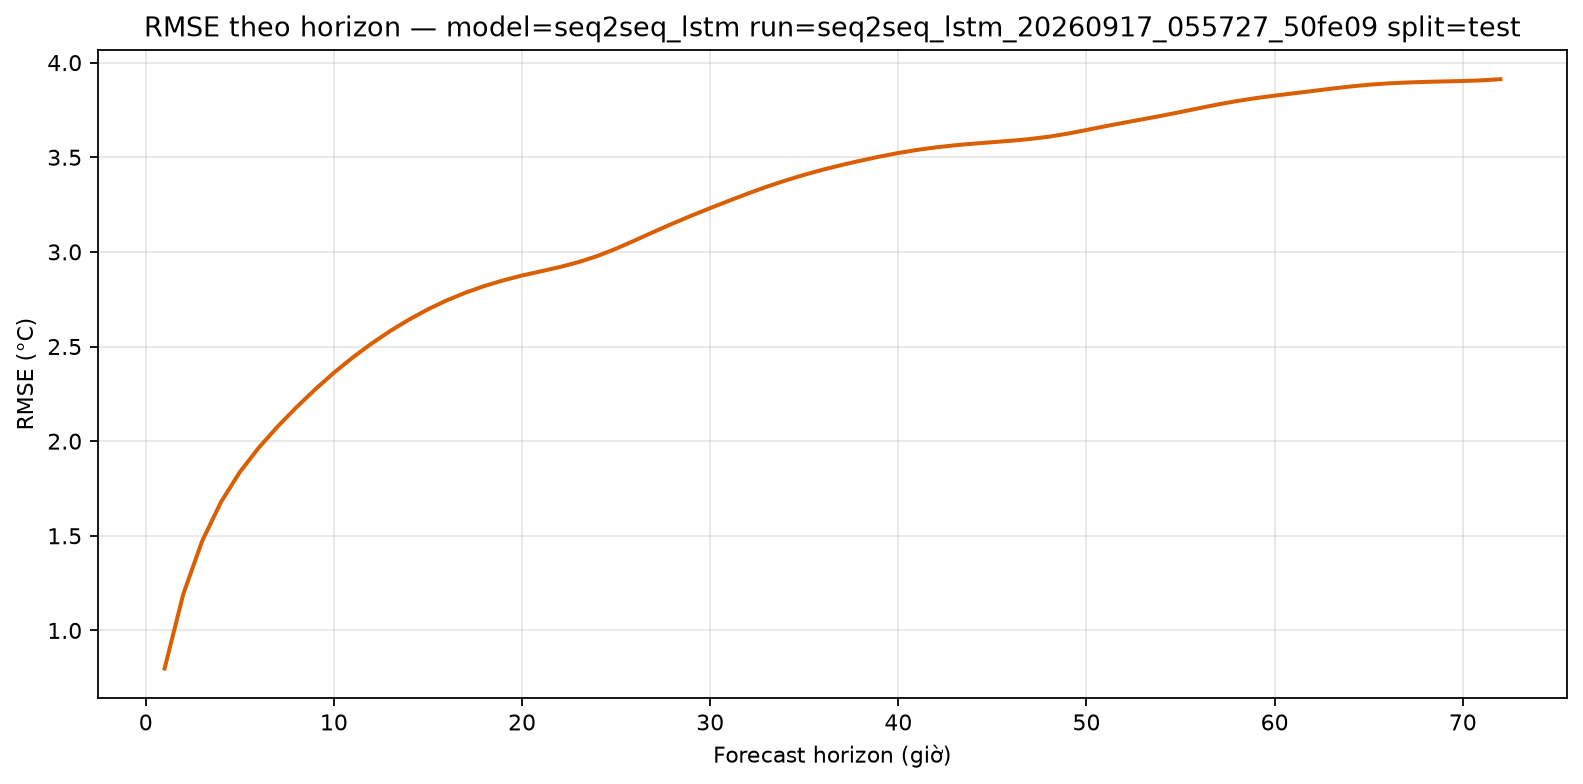

In [8]:
FIGURES_DIR = PROJECT_ROOT / "artifacts" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

error_frame = build_error_frame(
    y_true_degC, y_pred_degC, target_timestamps=target_timestamps,
    run_id=RUN_ID, model_name=resolved_config["model"]["name"], split="test",
)

forecast_fig_path = FIGURES_DIR / "forecast_vs_actual.png"
save_forecast_figure(
    error_frame, forecast_fig_path,
    run_id=RUN_ID, model_id=resolved_config["model"]["name"], split="test",
)
print(f"Đã lưu: {forecast_fig_path}")
display(Image(filename=str(forecast_fig_path)))

horizon_fig_path = FIGURES_DIR / "horizon_error.png"
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(per_horizon_df["Horizon"], per_horizon_df["RMSE"], color="#d95f02", linewidth=1.8)
ax.set_xlabel("Forecast horizon (giờ)")
ax.set_ylabel("RMSE (°C)")
ax.set_title(f"RMSE theo horizon — model={resolved_config['model']['name']} run={RUN_ID} split=test")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(horizon_fig_path, dpi=160, bbox_inches="tight")
plt.close(fig)
print(f"Đã lưu: {horizon_fig_path}")
display(Image(filename=str(horizon_fig_path)))


## PHẦN 10 — Export Artifact

**Input:** `metrics_table` (Phần 7), `error_frame` (Phần 9).

**Processing:**
1. Lưu bảng metric tổng thể → `artifacts/metrics/lstm_metrics.csv`.
2. Lưu prediction của cửa sổ đại diện (cùng cửa sổ ở Hình 1) →
   `artifacts/predictions/lstm_prediction.csv` (`timestamp, actual_temperature,
   predicted_temperature`) — chỉ 1 cửa sổ liên tục vì 3 cột này chỉ có nghĩa duy nhất khi
   timestamp không lặp lại giữa các cửa sổ chồng lấn.
3. 2 file hình đã lưu ở Phần 9.

**Output:**
```
artifacts/
├── metrics/lstm_metrics.csv
├── predictions/lstm_prediction.csv
└── figures/forecast_vs_actual.png, horizon_error.png
```


In [9]:
METRICS_DIR = PROJECT_ROOT / "artifacts" / "metrics"
PREDICTIONS_DIR = PROJECT_ROOT / "artifacts" / "predictions"
METRICS_DIR.mkdir(parents=True, exist_ok=True)
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

metrics_csv_path = METRICS_DIR / "lstm_metrics.csv"
metrics_table.to_csv(metrics_csv_path, index=False)

first_sample_id = error_frame["sample_index"].iloc[0]
representative = (
    error_frame.loc[error_frame["sample_index"] == first_sample_id, ["timestamp", "y_true", "y_pred"]]
    .rename(columns={"y_true": "actual_temperature", "y_pred": "predicted_temperature"})
    .sort_values("timestamp")
    .reset_index(drop=True)
)
prediction_csv_path = PREDICTIONS_DIR / "lstm_prediction.csv"
representative.to_csv(prediction_csv_path, index=False)

print("=== Checklist artifact cho Slide 8 ===")
for path in [metrics_csv_path, prediction_csv_path, forecast_fig_path, horizon_fig_path]:
    status = "OK" if path.is_file() else "Chưa có artifact"
    print(f"[{status}] {path.relative_to(PROJECT_ROOT)}")

print("\n=== Tóm tắt số liệu thật (split=test) ===")
print(f"Run ID: {RUN_ID}")
print(f"MAE  = {overall_metrics['mae']:.4f} °C")
print(f"RMSE = {overall_metrics['rmse']:.4f} °C")
print(f"MSE  = {overall_metrics['mse']:.4f} °C²")


=== Checklist artifact cho Slide 8 ===
[OK] artifacts\metrics\lstm_metrics.csv
[OK] artifacts\predictions\lstm_prediction.csv
[OK] artifacts\figures\forecast_vs_actual.png
[OK] artifacts\figures\horizon_error.png

=== Tóm tắt số liệu thật (split=test) ===
Run ID: seq2seq_lstm_20260917_055727_50fe09
MAE  = 2.5187 °C
RMSE = 3.2632 °C
MSE  = 10.6483 °C²
